In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# Base Model with 64x64 Image and 4 Conv Blocks
# Using OverSampled high-alert and 0.0075 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `BaseModel` from `architectures.BaseModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.BaseModel import BaseModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 8
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 8` 
* `initial_image_size = 64`

In [6]:
model = BaseModel(conv_layers=4, initial_output_channel=8, initial_image_size=64).to("cuda")

In [8]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=100,
    lr=0.0075,
    print_on=10,
    save_dir="../models/base_img64_c4_lr_0.0075_os/",
    save_checkpoints=10,
    checkpoint_name="base_64x64_train_0_"
)

Epoch 10/100 | Train Loss: 0.7893 | Validation Loss: 0.7983
Epoch 20/100 | Train Loss: 0.6505 | Validation Loss: 1.1653
Epoch 30/100 | Train Loss: 0.4857 | Validation Loss: 0.7719
Epoch 40/100 | Train Loss: 0.3409 | Validation Loss: 0.9950
Epoch 50/100 | Train Loss: 0.2273 | Validation Loss: 1.1646
Epoch 60/100 | Train Loss: 0.1473 | Validation Loss: 1.1972
Epoch 70/100 | Train Loss: 0.1003 | Validation Loss: 1.5282
Epoch 80/100 | Train Loss: 0.0696 | Validation Loss: 1.8940
Epoch 90/100 | Train Loss: 0.0245 | Validation Loss: 1.9077
Epoch 100/100 | Train Loss: 0.0031 | Validation Loss: 2.3221


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [9]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [10]:
metrics.head(10)

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,1,0.905153,0.520765,0.185906,0.333038,0.229451,0.871539,0.521389,0.173796,0.333333,0.228471
1,2,0.872779,0.521858,0.330842,0.333389,0.229659,0.876723,0.555697,0.366437,0.389649,0.377533
2,3,0.868761,0.521767,0.324142,0.333856,0.234495,0.873888,0.567980,0.384544,0.408940,0.390557
3,4,0.866066,0.523679,0.337962,0.336085,0.243960,0.861106,0.520542,0.173661,0.332792,0.228227
4,5,0.860236,0.528415,0.344500,0.343451,0.277633,0.861386,0.520966,0.284846,0.333130,0.228964
5,6,0.852123,0.532969,0.345332,0.353171,0.315174,0.866371,0.521813,0.351691,0.334142,0.233452
6,7,0.841081,0.555464,0.364202,0.376477,0.356486,0.976800,0.520966,0.173729,0.333063,0.228349
7,8,0.826882,0.570674,0.375164,0.391980,0.377572,0.823424,0.560356,0.408845,0.368472,0.315536
8,9,0.808217,0.595628,0.393165,0.412784,0.400043,0.818207,0.575604,0.401398,0.420946,0.393487
9,10,0.789285,0.619672,0.409632,0.431857,0.419225,0.798287,0.604405,0.405001,0.432765,0.415510


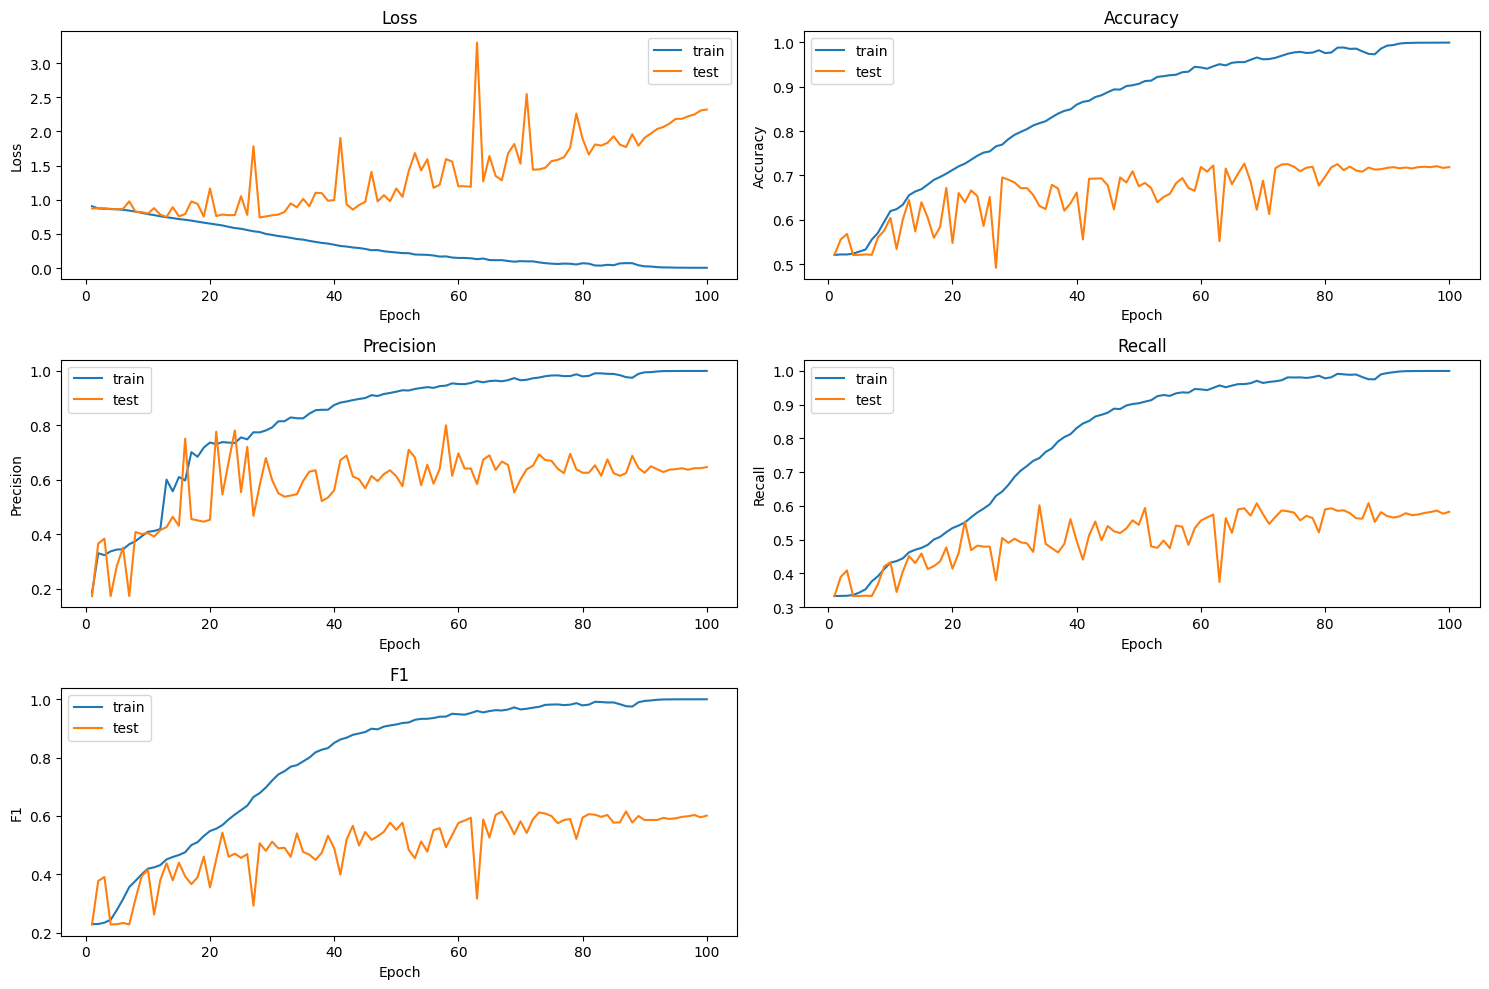

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"test_{metric}",
        ax=ax,
        label="test"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()